In [72]:
import pandas as pd
import seaborn as sns

In [73]:
#Creating a dataset
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0,random_state=10)

In [74]:
X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

In [75]:
X.head(5)

,feature_0,feature_1
0,-0.541855,0.057208
1,1.662027,-0.727590
2,0.948612,-0.982990
3,1.634751,1.600342
4,-1.770307,-2.189778


<Axes: xlabel='feature_0', ylabel='feature_1'>

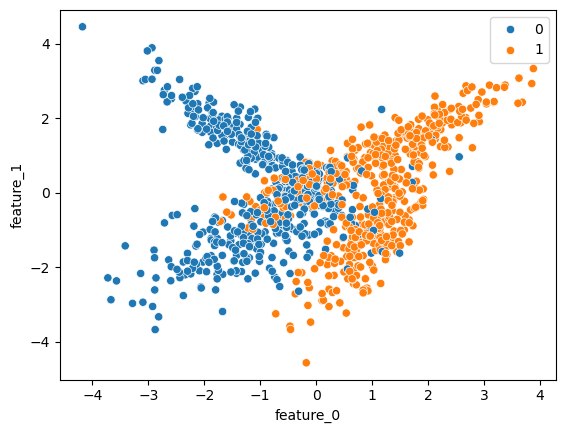

In [76]:
sns.scatterplot(x=X['feature_0'], y=X['feature_1'], hue=y)

In [77]:
from sklearn.svm import SVC
model = SVC(kernel='linear')

In [78]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [79]:
model.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [80]:
#Make predictions
y_pred = model.predict(X_test)

In [81]:
print(y_pred)

[1 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0
 1 1 0 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1
 0 0 1 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0
 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1
 1 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0]


In [82]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       131
           1       0.83      0.84      0.83       119

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250

0.84
[[110  21]
 [ 19 100]]


In [83]:
rbf = SVC(kernel='rbf')

In [84]:
rbf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [85]:
#Make predictions
y_pred = rbf.predict(X_test)

In [86]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       131
           1       0.87      0.81      0.84       119

    accuracy                           0.85       250
   macro avg       0.85      0.85      0.85       250
weighted avg       0.85      0.85      0.85       250

0.852
[[117  14]
 [ 23  96]]


In [88]:
pol = SVC(kernel='poly')
pol.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [89]:
#Make predictions
y_pred = pol.predict(X_test)

In [90]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.92      0.85       131
           1       0.89      0.72      0.80       119

    accuracy                           0.82       250
   macro avg       0.84      0.82      0.82       250
weighted avg       0.83      0.82      0.82       250

0.824
[[120  11]
 [ 33  86]]


Hyperparameter Tuning

In [91]:
param_grid = {
    'C' : [0.1,1,10,1000],
    'gamma' : [1,0.1,0.01,0.001],
    'kernel' : ['linear','rbf','poly']
}

In [95]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=SVC(),param_grid=param_grid,refit=True,verbose=3)

In [97]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.873 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.893 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.893 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.887 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.860 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.880 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [98]:
print(grid.best_params_)

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}


In [99]:
#Make predictions and evaluate
y_pred = grid.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       131
           1       0.87      0.82      0.84       119

    accuracy                           0.86       250
   macro avg       0.86      0.85      0.86       250
weighted avg       0.86      0.86      0.86       250

0.856
[[117  14]
 [ 22  97]]
